# Gaussian Distribution (Normal Distribution, Bell Curve)

## Parameterization and Probability Density Function (PDF)
The Gaussian distribution is parameterized by $\mu$ and $\sigma$ where:
- $\mu$ is the mean (expected value) of the distribution
- $\sigma$ is the standard deviation (measure of spread) of the distribution
- We often use the **standard Gaussian** where $\mu = 0$ and $\sigma = 1$. This is for standardizing variables to compare on equal footing (i.e. comparing degrees Celsius and hight mm have very different units)

The PDF of the Gaussian distribution is:
$$f(x) = \frac{1}{\sigma \sqrt{2\pi}}e^{-\frac{1}{2}\frac{(x-\mu)^2}{\sigma}}$$

## Features
<ol style="margin-bottom: 0;">
  <li><b>Symmetry - The distribution is symmetrical about the mean.</b></li>
    <ul style="margin-top: 0; margin-bottom: 0;">
      <li>This makes it much easier for calculating probabilities and making inferences about the data.</li>
    </ul>
  <li><b>The mean, median, and mode of a perfect Gaussian distribution are aligned (equal).</b>
    <ul style="margin-top: 0; margin-bottom: 0;">
      <li>When there is skew and/or kurtosis in the distribution, this is no longer true.</li>
    </ul>
  </li>
  <li><b>Empirical Rule of the standard normal distribution</b>
    <ul style="margin-top: 0; margin-bottom: 0;">
      <li>68% of the data is within one standard deviation of the mean.</li>
      <li>95% of the data is within two standard deviations of the mean.</li>
      <li>99.7% of the data is within three standard deviations of the mean.</li>
    </ul>
  </li>
  <li><b>Skew</b>
    <ul style="margin-top: 0; margin-bottom: 0;">
      <li><b>Right skew (positive skew)</b> - The tail on the right side is longer/fatter. The mean will be greater than the median, and the majority of the data is concentrated on the left.</li>
      <li><b>Left skew (negative skew)</b> - The tail on the left side is longer/fatter. The mean will be less than the median, and the majority of the data is concentrated on the right.</li>
    </ul>
  </li>
  <li><b>Kurtosis</b>
    <ul style="margin-top: 0; margin-bottom: 0;">
      <li><b>Leptokurtic</b> - Has a higher peak and heavier tails than a normal distribution. It means that the data has more extreme values or outliers than expected under normal conditions.</li>
      <li><b>Platykurtic</b> - Has a flatter peak and lighter tails compared to a normal distribution. It means that the data has fewer extreme values or outliers than expected under normal conditions.</li>
      <li><b>Mesokurtic</b> - Has the shape of a normal distribution with moderate tails.</li>
    </ul>
  </li>
</ol>

## Why is the Gaussian distribution important?
1. **The Central Limit Theorem (CLT)** - We can infer about the population with only a sample, and we are gauranteed by the CLT that the sampling distribution is normal.
2. **Experimentation** - Essential for statisitical tests and calculating p-values and confidence intervals.
3. **Machine Learning** - Often times an assumption about normality will simplify/speed up parameter estimation, alogirthm convergence, and general complexity.
4. **Real-World Data** - Not all data is normally distributed, but a lot of data is. The Gaussian distribution models a lot of real-world problems in the fields of biology (height, weight), sociology (polling), public health (medical cost), sports (retirement age), metric analysis (school grades), policy (income), etc.

## Calculating PDF and CDF

In [1]:
import numpy as np
from scipy.stats import norm
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [2]:
norm.pdf(0, loc=0, scale=1)

0.3989422804014327

In [3]:
norm.cdf(0, loc=0, scale=1)

0.5

In [4]:
# probability between two points a and b where a < b
def area_under_curve(a:float, b:float, mu:float, sigma:float) -> float:
    # calculate the cumulative probability up until a and up until b
    area_a = norm.cdf(a, mu, sigma)
    area_b = norm.cdf(b, mu, sigma)
    
    # subtract to get the difference
    area_c = area_b - area_a
    
    return area_c

In [5]:
print(area_under_curve(-1, 1, 0, 1))
print(area_under_curve(-2, 2, 0, 1))
print(area_under_curve(-3, 3, 0, 1))

0.6826894921370859
0.9544997361036416
0.9973002039367398


## Assesing Normality

In [6]:
# make a normal distribution with 1,000 data point
N = 1E3
normal_dist = norm.rvs(loc=0, scale=1, size=int(N))

### Histogram Plot
Each bin shows how many data points are in the interval. Should generally snow the bell curve shape.

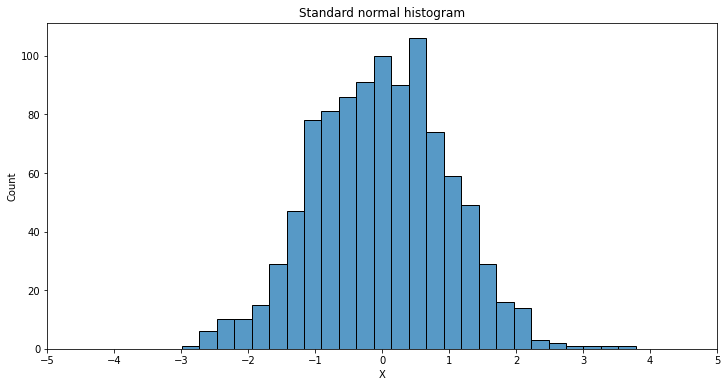

In [7]:
fig, ax = fig, ax = plt.subplots(figsize=(12, 6))
sns.histplot(data=normal_dist, ax=ax)
ax.set_title('Standard normal histogram')
ax.set_xlabel('X')

custom_ticks = np.arange(-5, 6, 1, dtype=None)
plt.xticks(ticks=custom_ticks)
plt.show()

### Kernel Density Plot (KDE)
Smoothed out version of the histogram plot. 

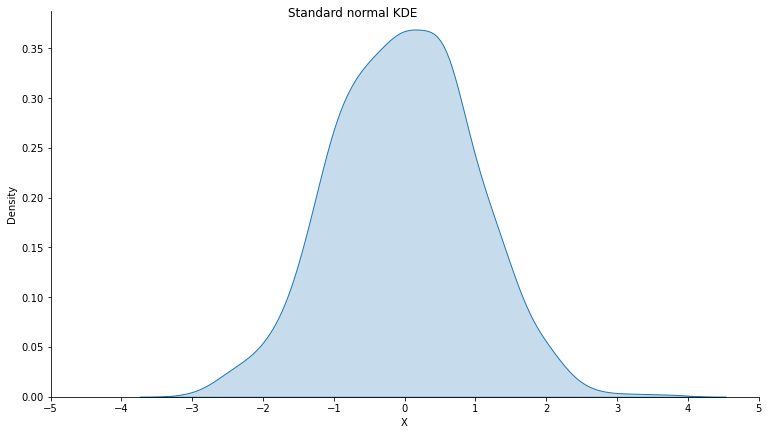

In [8]:
# plot the normal distribution with 1M data points
ax = sns.displot(data=normal_dist, kind='kde', fill=True)
ax.fig.suptitle('Standard normal KDE')
ax.set_xlabels('X')
ax.fig.set_size_inches(12, 6)

custom_ticks = np.arange(-5, 6, 1, dtype=None)
plt.xticks(ticks=custom_ticks)
plt.show()

### Quantile-Quantile Plot (QQ)
The QQ plot compares the quantiles of the observed data vs. the theoretical quantiles. 

Calculated by:
1. Sorting the data and assigning a rank i. 
2. Choosing a theoretical distribution to compare too. Doesn't have to be just normal. Can be t, chi squared, Poisson, etc.
3. Convert the rank into a probability. One example is $p_i = \frac{i-0.5}{N}$ where $N$ is the total number of data points.
4. Calculate the corresponding value from the underlying distribution using the inverse CDF.
5. Plot the sorted quantiles vs. the theoretical quantiles.

To intepret the QQ plot use the following:
<ol style="margin-bottom: 0;">
  <li><b>Normally Distributed</b></li>
    <ul style="margin-top: 0; margin-bottom: 0;">
      <li>The points fall closely along the diagonal reference line. Small, random variations at the extremes are normal, but the overall trend is linear.</li>
    </ul>
  <li><b>Right-Skewed (Positively Skewed)</b>
    <ul style="margin-top: 0; margin-bottom: 0;">
      <li>The points form a "smile" or concave-up shape. The data points start below the line, curve up, and then curve significantly above the line on the right side.</li>
    </ul>
  </li>
  <li><b>Left-Skewed (Negatively Skewed)</b>
    <ul style="margin-top: 0; margin-bottom: 0;">
      <li>The points form a "frown" or concave-down shape. The points start above the line on the left, curve downward, and fall below the line on the right.</li>
    </ul>
  <li><b>Leptokurtic (Heavier Tails than Normal)</b></li>
    <ul style="margin-top: 0; margin-bottom: 0;">
      <li>The points form an "S" shape, curving above the line at the top right and below the line at the bottom left. This means your data has more extreme outliers than expected.</li>
    </ul>
  <li><b>Platykurtic (Lighter Tails than Normal)</b></li>
    <ul style="margin-top: 0; margin-bottom: 0;">
      <li>The points form an inverted "S" shape, curving below the line at the top right and above the line at the bottom left.</li>
    </ul>
    <li><b>Outliers</b></li>
    <ul style="margin-top: 0; margin-bottom: 0;">
      <li>Isolated dots scattered far from the straight line, particularly at one or both ends, indicate individual outliers.</li>
    </ul>
</ol>

C:\Users\Austin\anaconda3\lib\site-packages\statsmodels\graphics\gofplots.py:993: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "bo" (-> marker='o'). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)


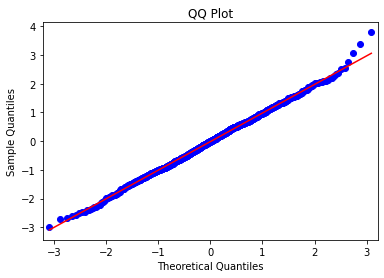

In [9]:
# Create a QQ plot
sm.qqplot(normal_dist, line='s')

# Set plot title
plt.title('QQ Plot')

# Display the plot
plt.show()

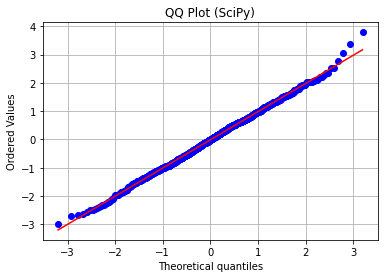

In [10]:
stats.probplot(normal_dist, dist="norm", plot=plt)
plt.title("QQ Plot (SciPy)")
plt.grid(True)
plt.show()

### Statitistical Tests

<ol style="margin-bottom: 0;">
  <li><b>Shapiro-Wilk</b></li>
    <ul style="margin-top: 0; margin-bottom: 0;">
      <li>Best suited for small to medium data sets (less than several hundred data points).</li>
      <li>Compares the order statistics of the data with those expected from a normal distribution.</li>
    </ul>
  <li><b>Kolmogorov-Smirnov</b>
    <ul style="margin-top: 0; margin-bottom: 0;">
      <li>Best suited for medium data sets (several hundred to several thousand).</li>
      <li>Compares the empirical distribution function of the sample with the cumulative distribution function of the normal distribution.</li>
    </ul>
  <li><b>Anderson-Darling</b>
    <ul style="margin-top: 0; margin-bottom: 0;">
      <li>Measures how well the data follow a normal distribution, giving more weight to the tails.</li>
    </ul>
</ol>

**Note** - generally all tests at high enough sample size will show deviations from normal. If you are working with large enough data you should visually inspect for normality.

In [11]:
# Shapiro-Wilk
test = stats.shapiro(normal_dist)
print(test.statistic, test.pvalue)

0.9985494613647461 0.5872126221656799


In [12]:
# Kolmogorov-Smirnov
test = stats.kstest(normal_dist, cdf='norm')
print(test.statistic, test.pvalue)

0.021600679117572907 0.7306827230928894


In [13]:
# Anderson-Darling
test = stats.anderson(normal_dist, dist='norm')
print(test.statistic, test.critical_values, test.significance_level)

0.30429397390480517 [0.574 0.653 0.784 0.914 1.088] [15.  10.   5.   2.5  1. ]


## Transforming Data to Normal

<ol style="margin-bottom: 0;">
  <li><b>Log Transformation</b></li>
    <ul style="margin-top: 0; margin-bottom: 0;">
      <li>Ideal when the standard deviation is proportional to the mean. If your data contains zeros or negative numbers, shift values by adding a constant first - e.g. $\log(x+c)$.</li>
    </ul>
  <li><b>Square Root Transformation</b>
    <ul style="margin-top: 0; margin-bottom: 0;">
      <li>Often used for count data where the variance is proportional to the mean.</li>
    </ul>
  <li><b>Reciprocal Transformation</b>
    <ul style="margin-top: 0; margin-bottom: 0;">
      <li>Measures how well the data follow a normal distribution, giving more weight to the tails.</li>
    </ul>
  <li><b>Box-Cox Transformation</b>
    <ul style="margin-top: 0; margin-bottom: 0;">
      <li>Use when your data is strictly positive and severely right-skewed (long right tail). It reverses the scale of your data, making large values smaller and small values larger, which pulls in the extreme right tail to achieve normality.</li>
    </ul>
</ol>

In [14]:
# log transformation 
log_data = np.log(normal_dist + 5)

# getting error because including 0 or negative numbers

In [15]:
# square root
sqr_data = (normal_dist+5)**(1/2)

# getting error because including negative numbers

In [16]:
reciprocal_data = 1/normal_dist

In [17]:
bcx_data, lam = stats.boxcox(normal_dist+5)
lam

0.9353132135605563